# 14. Comparacion con baseline LiDAR real

Este notebook compara el registro temporal de la pseudo-LiDAR con un baseline usando `LIDAR_TOP` real. La idea no es cambiar la pipeline principal, sino estimar que rendimiento alcanza el mismo backend de registro cuando la geometria de entrada procede de un sensor metrico real.

Mensaje principal: el baseline con LiDAR real permite estimar que rendimiento alcanza el mismo backend de registro cuando la geometria de entrada procede de un sensor metrico real. La comparacion con pseudo-LiDAR ayuda a separar las limitaciones del algoritmo de registro de las limitaciones propias de la representacion generada desde camaras.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.options.display.float_format = '{:.3f}'.format

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
BASE_DIR = ROOT / 'outputs' / 'scene-0061'
SCRIPT_PATH = ROOT / 'scripts' / 'evaluate_lidar_registration_baseline.py'
OUTPUT_PATH = BASE_DIR / 'lidar_registration_baseline.json'
CSV_PATH = BASE_DIR / 'lidar_registration_baseline.csv'
FIGURE_PATH = BASE_DIR / 'lidar_vs_pseudolidar_registration_baseline.png'

ROOT, BASE_DIR

(PosixPath('/home/clara/ml-depth-pro/slam_readiness_nuscenes'),
 PosixPath('/home/clara/ml-depth-pro/slam_readiness_nuscenes/outputs/scene-0061'))

## Ejecutar o cargar el baseline

Si el JSON ya existe, se carga directamente. Si no existe y `NUSCENES_ROOT` esta definido, se ejecuta el script reproducible.

In [2]:
if not OUTPUT_PATH.exists():
    nuscenes_root = os.environ.get('NUSCENES_ROOT')
    if nuscenes_root is None:
        raise RuntimeError('No existe lidar_registration_baseline.json y NUSCENES_ROOT no esta definido.')
    cmd = [
        sys.executable,
        str(SCRIPT_PATH),
        '--run-summary', str(BASE_DIR / 'run_summary.json'),
        '--dataroot', nuscenes_root,
        '--version', 'v1.0-mini',
        '--output', str(OUTPUT_PATH),
    ]
    print(' '.join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f'El baseline LiDAR ha fallado con codigo {result.returncode}')

lidar_baseline = json.loads(OUTPUT_PATH.read_text(encoding='utf-8'))
lidar_rows = pd.read_csv(CSV_PATH)
print('Pares evaluados:', lidar_baseline['num_pairs'])
print('Regiones:', ', '.join(lidar_baseline['regions']))

Pares evaluados: 4
Regiones: all, front, near, mid, far


## Resultados LiDAR por metodo y region

La region `all` usa el LiDAR completo, igual que la evaluacion base de pseudo-LiDAR. Las regiones `front`, `near`, `mid` y `far` usan el mismo soporte espacial que los analisis regionales.

In [3]:
agg_rows = []
for method, regions in lidar_baseline['aggregate'].items():
    for region_name, metrics in regions.items():
        agg_rows.append({'method': method, 'region': region_name, **metrics})
lidar_agg_df = pd.DataFrame(agg_rows).set_index(['method', 'region'])
display(lidar_agg_df)

translation_error_mean_m  rotation_error_mean_deg  \
method          region                                                      
icp_direct      all                        0.065                    0.216   
                front                      3.521                    1.489   
                near                       4.044                    4.029   
                mid                        2.576                    1.036   
                far                        3.023                    0.589   
global_then_icp all                        0.066                    0.217   
                front                      2.951                    1.446   
                near                       4.762                   12.480   
                mid                        2.583                    1.060   
                far                        0.194                    0.361   

                        fitness_mean  rmse_mean  num_source_points_mean  \
method          region                                                    
icp_direct      all            0.864      0.566               34704.000   
                front          0.880      0.583               13129.000   
                near           0.980      0.406               16706.500   
                mid            0.727      0.620                4124.250   
                far            0.623      0.773                1605.500   
global_then_icp all            0.864      0.567               34704.000   
                front          0.859      0.578               13129.000   
                near           0.899      0.487               16706.500   
                mid            0.727      0.623                4124.250   
                far            0.704      0.624                1605.500   

                        num_target_points_mean  num_valid_pairs  
method          region                                           
icp_direct      all                  34720.000                4  
                front                13673.500                4  
                near                 17669.000                4  
                mid                   3517.250                4  
                far                   1606.250                4  
global_then_icp all                  34720.000                4  
                front                13673.500                4  
                near                 17669.000                4  
                mid                   3517.250                4  
                far                   1606.250                4

## Comparacion con pseudo-LiDAR

Se comparan los resultados LiDAR con los JSON ya generados de pseudo-LiDAR. Esto permite ver cuanto se aleja la pseudo-LiDAR del sensor metrico real usando un backend de registro comparable.

In [4]:
pairwise = json.loads((BASE_DIR / 'pairwise_registration_metrics.json').read_text(encoding='utf-8-sig'))
region = json.loads((BASE_DIR / 'pairwise_region_analysis.json').read_text(encoding='utf-8-sig'))
front_best = json.loads((BASE_DIR / 'front_best_combination.json').read_text(encoding='utf-8-sig'))

comparison_rows = [
    {
        'configuracion': 'LiDAR real all + ICP',
        **lidar_baseline['aggregate']['icp_direct']['all'],
    },
    {
        'configuracion': 'LiDAR real all + global+ICP',
        **lidar_baseline['aggregate']['global_then_icp']['all'],
    },
    {
        'configuracion': 'pseudo-LiDAR all + ICP',
        'translation_error_mean_m': pairwise['aggregate']['pseudo_translation_error_mean_m'],
        'rotation_error_mean_deg': pairwise['aggregate']['pseudo_rotation_error_mean_deg'],
        'fitness_mean': pairwise['aggregate']['pseudo_fitness_mean'],
        'rmse_mean': None,
        'num_valid_pairs': pairwise['num_pairs'],
    },
    {
        'configuracion': 'pseudo-LiDAR front + ICP',
        **region['aggregate']['front'],
    },
    {
        'configuracion': 'pseudo-LiDAR front cfg05',
        **front_best['aggregate']['front_baseline_cfg05'],
    },
]
comparison_df = pd.DataFrame(comparison_rows).set_index('configuracion')
display(comparison_df)

,translation_error_mean_m,rotation_error_mean_deg,fitness_mean,rmse_mean,num_source_points_mean,num_target_points_mean,num_valid_pairs
configuracion,,,,,,,
LiDAR real all + ICP,0.065,0.216,0.864,0.566,34704.000,34720.000,4
LiDAR real all + global+ICP,0.066,0.217,0.864,0.567,34704.000,34720.000,4
pseudo-LiDAR all + ICP,1.506,1.274,0.754,NaN,NaN,NaN,4
pseudo-LiDAR front + ICP,1.906,2.330,0.752,NaN,NaN,NaN,4
pseudo-LiDAR front cfg05,1.179,1.598,0.748,0.620,NaN,NaN,4


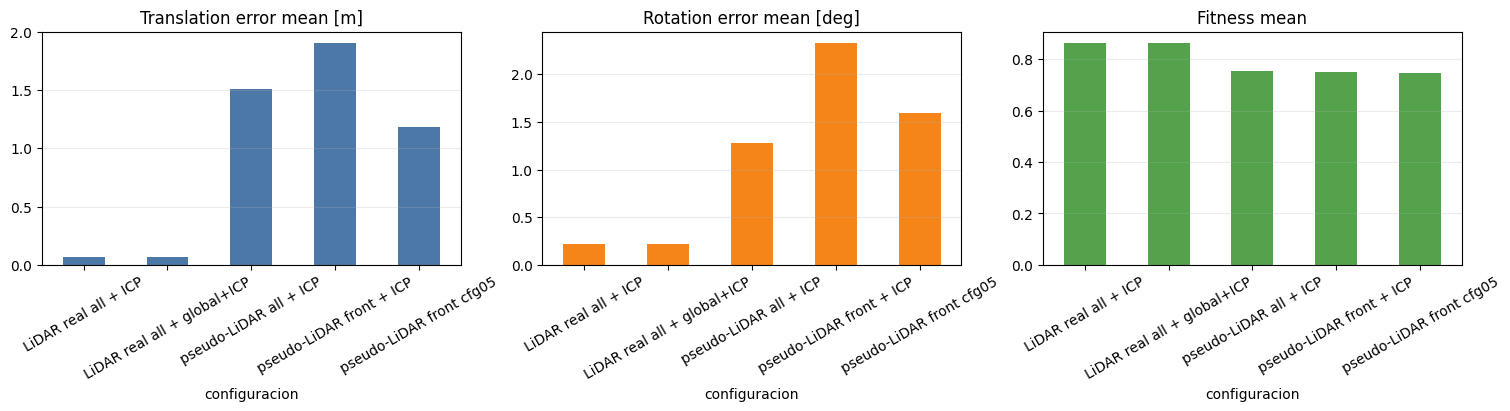

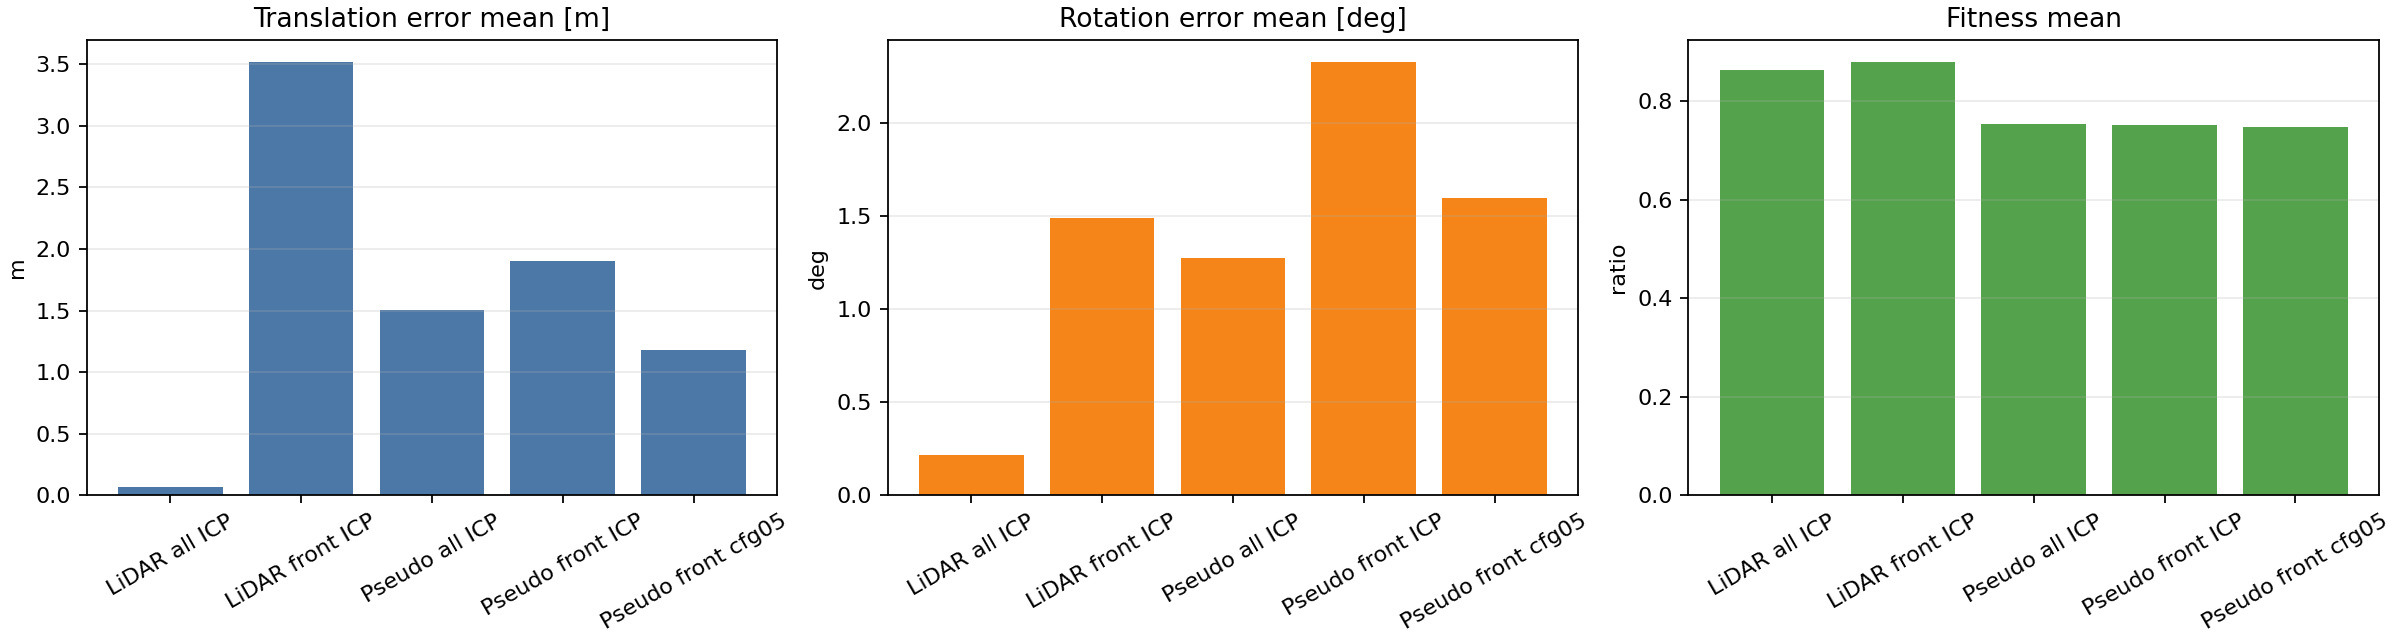

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
comparison_df['translation_error_mean_m'].plot(kind='bar', ax=axes[0], color='#4C78A8', title='Translation error mean [m]')
comparison_df['rotation_error_mean_deg'].plot(kind='bar', ax=axes[1], color='#F58518', title='Rotation error mean [deg]')
comparison_df['fitness_mean'].plot(kind='bar', ax=axes[2], color='#54A24B', title='Fitness mean')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.25)
plt.show()

if FIGURE_PATH.exists():
    display(Image(filename=str(FIGURE_PATH)))

## Interpretacion

Con el LiDAR completo, el mismo backend de ICP obtiene un error muy bajo. Esto confirma que el backend puede registrar correctamente cuando la geometria de entrada es fiable. En cambio, la pseudo-LiDAR presenta un error mayor, por lo que una parte importante de la diferencia se atribuye a la representacion generada desde camaras: ruido de profundidad, huecos, inconsistencias temporales y cobertura no uniforme.

El resultado no invalida la pseudo-LiDAR. La posiciona como una representacion intermedia util, pero no equivalente al LiDAR real. Su utilidad aumenta al seleccionar regiones mas estables y al ajustar la estrategia de registro.